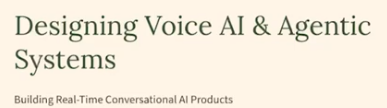

## Why Voice AI Is a Real-Time Systems Problem

Voice AI shifts the architectural challenge from static throughput to ultra-low latency constraints, making it fundamentally a real-time systems problem.

---

### Batch / High-Latency vs. Real-Time Streaming Response

* **Batch / High-Latency Response**:
* The flow relies on sequential processing steps: user speaks $\rightarrow$ audio uploaded $\rightarrow$ model processes $\rightarrow$ full response returned.


* Even a $2\text{--}3\text{ second}$ delay makes the conversation feel broken to the user.


* Interruptions are ignored, and turn-taking mechanisms remain rigid.




* **Real-Time Streaming Response**:
* Employs continuous audio streaming where partial transcripts feed the model and tokens stream directly to text-to-speech (TTS).


* Audio begins playing before generation is fully complete, dropping latency below $500\text{ms}$ and handling interruptions gracefully.





> **Core Insight**: Model quality alone cannot compensate for poor latency. A slower, more accurate model often **performs worse** in production voice UX than a faster, slightly less accurate one.
> 
>

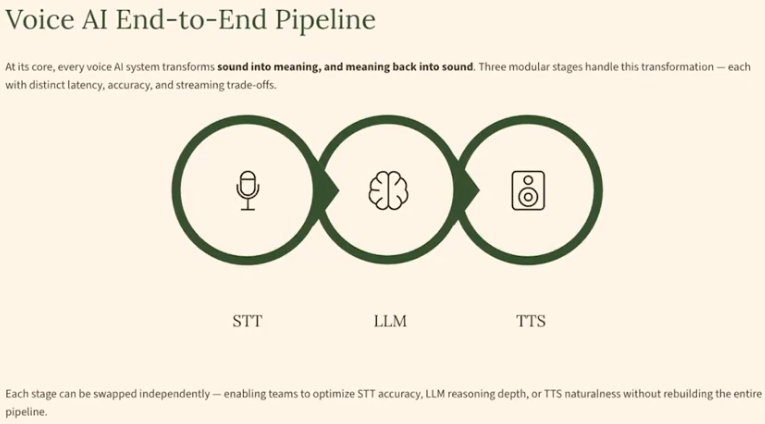

## Real-Time Voice AI Streaming Architecture

Production voice systems require every component to stream continuously—not in batches.

---

### Key Principles of Streaming Voice Architecture

* **Continuous Data Flow**: Every pipeline component operates on streaming inputs and outputs rather than waiting for complete blocks.


* **Latency Checkpoints**: Measures and optimizes latency at each distinct handoff stage across the pipeline.

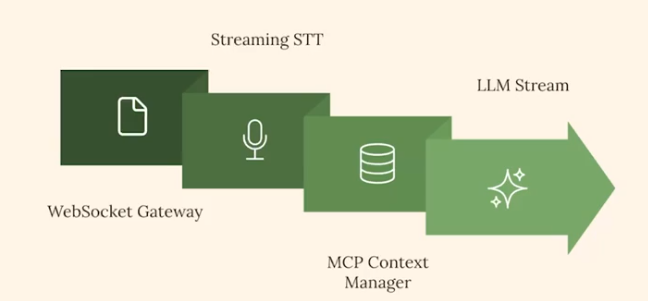

## REST vs. WebSockets for Conversational AI

---

### REST — Request / Response

* **Client Behavior**: Client sends the complete audio payload.


* **Server Behavior**: Server processes the request, then returns a full response.


* **Connection Lifecycle**: Connection closes after each round trip.


* **Latency Profile**: Latency equals the entire processing time before the first byte.


* **Evaluation**: Simple to implement, but unacceptable for live conversation.



---

### WebSockets — Persistent Streaming

* **Connection Lifecycle**: A single persistent connection is maintained throughout the session.


* **Data Flow**: Audio chunks are streamed continuously in both directions.


* **Delivery Mechanism**: Partial results are delivered as they are generated.


* **Latency Profile**: Latency is measured by time to first chunk, not the full response.


* **Evaluation**: Production-grade and enables interruption handling.

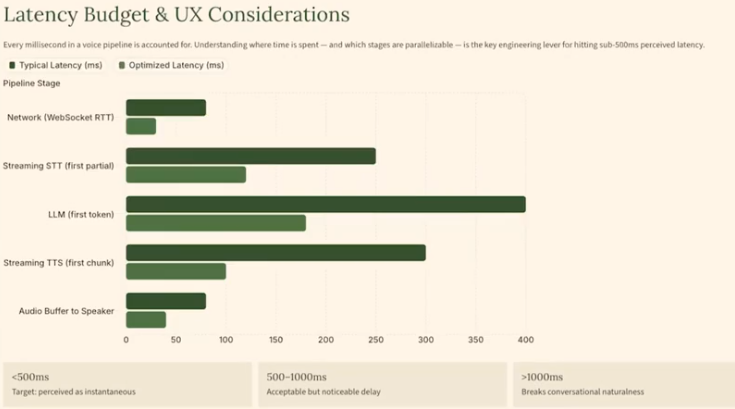

## From Voice Demos to Voice Products

Most voice AI demos are single-path, happy-path prototypes. Shipping a **production voice product** requires engineering every failure mode, edge case, and UX nuance that demos conveniently skip.

---

### Evolutionary Stages of Voice AI

* **Voice Demo**:
* Single-turn, scripted, features no interruptions or error handling, and relies on fixed network conditions.


* Impressive in a controlled setting, but fundamentally limited.




* **Real-Time System**:
* Implements a streaming pipeline equipped with barge-in detection, partial transcripts, fallback strategies, turn management, and session state.




* **Voice Product**:
* Multi-tenant, observable, monitored, tested, scalable, latency-budgeted, and accessible.


* Continuously improving in production environments.

## What Is an AI Agent?

An AI agent goes beyond a standard chatbot by functioning as a system that autonomously reasons about goals, plans action sequences, selects tools, executes them, and updates its understanding in an ongoing loop.

---

### Core Pillars of an AI Agent

* **Reason**: Breaks complex goals down into smaller sub-tasks using chain-of-thought reasoning or structured planning.


* **Act**: Interacts with external tools—such as APIs, databases, search engines, and code executors—to gather information or effect change.


* **Remember**: Maintains context across multiple turns and sessions, which enables the completion of long-horizon tasks.


* **Iterate**: Observes outcomes, verifies results, and refines its plan autonomously without requiring human intervention at every step.

## AI Agent Reasoning Loop

The agent loop serves as the heartbeat of every autonomous system. In each cycle, the system processes input, plans a course of action, executes tools, observes results, updates memory, and produces a verified response before repeating the process.

---

### Key Stages of the Reasoning Loop

* **Input**: Captures and processes the initial user prompt or environment state.


* **Plan**: Structures a sequence of actions or decomposition of goals.


* **Tool Selection**: Identifies and selects the appropriate external utilities or APIs required for the task.


* **Execute & Observe**: Runs the selected actions and observes the resulting outcomes.



> **Exit Condition**: The loop only exits when the **Verification** stage determines the goal is satisfied—or when a maximum iteration limit is reached. This iterative feedback loop is what makes agents fundamentally different from single-pass LLM calls.
> 
>

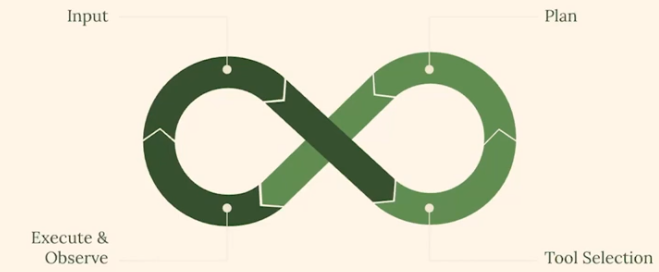

## Tool Calling & Action Execution

---

### How Agents Use Tools

When an LLM generates a tool call (a structured JSON payload), the agent runtime intercepts it, routes it to the correct service, executes it, and returns the result as an observation—all within a single loop iteration.

### Step-by-Step Execution Flow

* **01. LLM emits tool call JSON**: The model structures its request into a tool-call payload.


* **02. Runtime routes to registered tool**: The agent runtime intercepts the output and directs it to the appropriate registered service.


* **03. Tool executes and returns result**: The external service or tool runs the action and produces an output.


* **04. Result injected back into context**: The observation is fed back into the context window for the next stage of the loop.

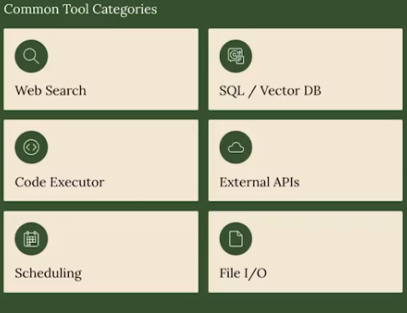

## Memory & Long-Term Context in Agents

---

### Three Layers of Agent Memory

* **1. In-Context Memory**:
* Represents the active conversation window.


* It is fast and immediately accessible, but strictly limited by the model's context length and lost when the session ends.




* **2. Episodic Memory**:
* Consists of recent interaction summaries stored externally and retrieved per session.


* It enables continuity across conversations without overloading the context window.




* **3. Semantic Memory**:
* Comprises long-term facts stored securely in a vector database.


* Retrieved via embedding similarity search, giving agents access to organizational knowledge at scale.





> **Production Best Practice**: Production agents typically combine all three layers: the context window holds the current task, episodic memory provides session continuity, and semantic memory grounds responses in verified knowledge.
> 
>

## When Multi-Agent Systems Make Sense

A single agent works well for focused, linear tasks, but when problems are parallel, specialized, or too large for one context window, multi-agent architectures unlock powerful new capabilities.

---

### Core Advantages of Multi-Agent Systems

* **1. Parallel Execution**: Sub-agents run independent tasks simultaneously, which dramatically reduces end-to-end latency for complex workflows.


* **2. Specialization**: Each agent is fine-tuned for a specific domain—such as research, coding, or summarization—and coordinated by an overarching orchestrator.


* **3. Fault Isolation**: A failing sub-agent does not crash the entire system, as the orchestrator can retry, reroute, or degrade functionality gracefully.



---

### Common Multi-Agent Patterns

* **Orchestrator $\rightarrow$ Workers**: A central planner delegates tasks to specialist agents.


* **Pipeline**: A sequential handoff where each agent processes the output of the previous one.


* **Debate**: Multiple agents propose solutions, and a designated judge selects the best option.


* **Supervisor**: A monitoring agent validates outputs before final delivery.